# Supply Chain Performance & Operations Analytics Dashboard

---

## Phase 3 — Anomaly Detection & Supplier Risk Scoring

Phases 1 and 2 cleaned and structured the raw data. Phase 3 adds the
**machine learning layer** — the analytical component that separates
this dashboard from standard reporting and makes it genuinely intelligent.

We automatically identify which orders behave unusually and which
supplier segments carry the highest operational risk — without a human
manually reviewing 65,749 orders.

### Key design decisions
> **Anomaly detection runs at order level (65,749 unique orders)**,
> not at item level (180,516 rows). Running on item rows would flag
> the same order multiple times if it contains multiple products.
> Anomaly flags are then mapped back to item level for Power BI.

> **Risk score threshold set at 65** (not 70) based on the observed
> score distribution — the top segments cluster between 65–70 with
> late delivery rates of 80–94%. This is a documented judgment call.

### What this notebook does
| Step | Task |
|---|---|
| 1 | Load Phase 2 outputs and verify integrity |
| 2 | Fix dim_date timestamp issue (65,749 → ~1,127 rows) |
| 3 | Aggregate item-level data to order level for ML |
| 4 | Select and standardise 7 features for Isolation Forest |
| 5 | Run anomaly detection on 65,749 unique orders |
| 6 | Map anomaly flags back to item level for Power BI |
| 7 | Validate anomalies via manual comparison |
| 8 | Compute weighted supplier risk scores (0–100) |
| 9 | Assign High / Medium / Low risk tier labels |
| 10 | Export all enriched tables |
| 11 | Run full Power BI readiness validation |

### Carrying forward from Phase 2
- `fact_orders_enriched.csv` — 180,516 item rows, 65,749 unique orders
- `fact_orders_summary.csv` — 65,749 order-level rows
- `dim_date.csv` — needs timestamp fix before use

---
> **ML Algorithm:** Isolation Forest (scikit-learn)
> **Contamination:** 5% — industry convention for unlabelled data
> **Risk threshold:** High Risk ≥ 65, Medium Risk 40–64, Low Risk < 40
> **Input:** Phase 2 processed CSVs from `data\processed\`
> **Output:** 3 updated CSVs + 1 fixed CSV
> **Next:** Phase 4 — Power BI Dashboard Development

# Import Libraries

In [1]:
# Standard libraries 
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick   # For formatting axis labels as percentages
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Machine learning 
from sklearn.ensemble import IsolationForest
# IsolationForest lives in sklearn's ensemble module —
# ensemble means a group of decision trees working together

from sklearn.preprocessing import StandardScaler
# StandardScaler puts all features on the same scale
# so no feature dominates just because its numbers are bigger

# Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# File paths 
BASE_PATH   = r'C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard'
PROCESSED   = BASE_PATH + r'\data\processed'
OUTPUT_PATH = PROCESSED   # We export back to the same folder

print("Setup complete.")
print(f" Working folder: {PROCESSED}")

Setup complete.
 Working folder: C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard\data\processed


# Load Phase 2 Files

In [2]:
# Load the two main tables from Phase 2 
fact_orders = pd.read_csv(
    os.path.join(PROCESSED, 'fact_orders_enriched.csv'),
    encoding='utf-8-sig'
)

order_summary = pd.read_csv(
    os.path.join(PROCESSED, 'fact_orders_summary.csv'),
    encoding='utf-8-sig'
)

dim_geo = pd.read_csv(
    os.path.join(PROCESSED, 'dim_geo.csv'),
    encoding='utf-8-sig'
) if os.path.exists(os.path.join(PROCESSED, 'dim_geo.csv')) else None

print(f"✅ fact_orders   : {fact_orders.shape[0]:,} rows × {fact_orders.shape[1]} columns")
print(f"✅ order_summary : {order_summary.shape[0]:,} rows × {order_summary.shape[1]} columns")
if dim_geo is not None:
    print(f"✅ dim_geo       : {dim_geo.shape[0]:,} rows × {dim_geo.shape[1]} columns")

# Verify key columns exist 
required_cols = [
    'Order Id', 'actual_delay_days', 'is_late',
    'profit_margin_pct', 'Shipping Mode', 'supplier_segment'
]
missing_cols = [c for c in required_cols if c not in fact_orders.columns]

if missing_cols:
    print(f"\n❌ Missing required columns: {missing_cols}")
    print("   Re-run Notebook 02 before continuing.")
else:
    print(f"\n✅ All required columns present")

# Confirm dataset grain 
# Reminder: fact_orders is at ORDER-ITEM level, order_summary is at ORDER level
unique_orders_fact    = fact_orders['Order Id'].nunique()
unique_orders_summary = order_summary['Order Id'].nunique()

print(f"\n Dataset grain confirmation:")
print(f"   fact_orders item rows    : {len(fact_orders):,}")
print(f"   fact_orders unique orders: {unique_orders_fact:,}")
print(f"   order_summary rows       : {len(order_summary):,}")
print(f"   Grain match              : {'✅' if unique_orders_fact == unique_orders_summary else '❌ MISMATCH'}")

✅ fact_orders   : 180,516 rows × 26 columns
✅ order_summary : 65,749 rows × 20 columns

✅ All required columns present

 Dataset grain confirmation:
   fact_orders item rows    : 180,516
   fact_orders unique orders: 65,749
   order_summary rows       : 65,749
   Grain match              : ✅


# Fix dim_date Timestamp
Phase 2 exported `dim_date` with 65,749 rows because timestamps included hours and minutes. A proper date dimension needs one row per calendar day — not one row per timestamp. Power BI's time intelligence functions require this.
Strips the time component from all order dates, builds a clean dim_date with one row per calendar day, adds 10 date components for Power BI time intelligence, and immediately exports. Row count should drop from 65,749 to around 1,127.

In [3]:
# Rebuild dim_date with calendar dates only 
date_col = 'order date (DateOrders)'

# Re-parse the date column — it was loaded as string from CSV
fact_orders[date_col] = pd.to_datetime(fact_orders[date_col], errors='coerce')
order_summary[date_col] = pd.to_datetime(order_summary[date_col], errors='coerce')

# .dt.date extracts only the calendar date portion (drops hours/minutes/seconds)
unique_dates = fact_orders[date_col].dt.date.dropna().unique()

# Build a clean date DataFrame — one row per unique calendar day
dim_date = pd.DataFrame({'order_date': pd.to_datetime(unique_dates)})
dim_date = dim_date.sort_values('order_date').reset_index(drop=True)

# Extract all date components Power BI needs for time intelligence 
dim_date['year']         = dim_date['order_date'].dt.year
dim_date['month']        = dim_date['order_date'].dt.month
dim_date['month_name']   = dim_date['order_date'].dt.strftime('%B')   # January
dim_date['month_abbr']   = dim_date['order_date'].dt.strftime('%b')   # Jan
dim_date['quarter']      = dim_date['order_date'].dt.quarter           # 1–4
dim_date['quarter_name'] = 'Q' + dim_date['quarter'].astype(str)      # Q1
dim_date['day_of_week']  = dim_date['order_date'].dt.dayofweek        # 0=Mon
dim_date['day_name']     = dim_date['order_date'].dt.strftime('%A')   # Monday
dim_date['is_weekend']   = (dim_date['day_of_week'] >= 5).astype(int) # 1=weekend
dim_date['week_number']  = dim_date['order_date'].dt.isocalendar().week.astype(int)

# Export fixed dim_date immediately 
dim_date.to_csv(
    os.path.join(OUTPUT_PATH, 'dim_date.csv'),
    index=False, encoding='utf-8-sig'
)

print(f"✅ dim_date rebuilt and exported:")
print(f"   Rows before fix : 65,749 (one per timestamp)")
print(f"   Rows after fix  : {dim_date.shape[0]:,} (one per calendar day)")
print(f"   Date range      : {dim_date['order_date'].min().date()} → "
      f"{dim_date['order_date'].max().date()}")
print(f"   Years covered   : {sorted(dim_date['year'].unique().tolist())}")
print(f"   Columns         : {dim_date.shape[1]}")

✅ dim_date rebuilt and exported:
   Rows before fix : 65,749 (one per timestamp)
   Rows after fix  : 1,127 (one per calendar day)
   Date range      : 2015-01-01 → 2018-01-31
   Years covered   : [2015, 2016, 2017, 2018]
   Columns         : 11


# Aggregate to Order Level

### Why aggregate before anomaly detection?
`fact_orders` has 180,516 rows but only 65,749 unique orders. Running Isolation Forest on item-level rows means the same order gets flagged multiple times if it has 3 items — producing misleading results. We must detect anomalies at order level where each order is one observation.

In [4]:
# Aggregate fact_orders from item level to order level 
print("Aggregating to order level for anomaly detection...\n")

order_agg = fact_orders.groupby('Order Id').agg(
    # Delivery metrics — take first value (same for all items in an order)
    actual_delay_days       = ('actual_delay_days',            'first'),
    days_shipping_real      = ('Days for shipping (real)',      'first'),
    days_shipping_scheduled = ('Days for shipment (scheduled)', 'first'),
    is_late                 = ('is_late',                      'first'),

    # Financial metrics — aggregate across all items in the order
    total_sales             = ('Sales',                        'sum'),
    total_profit            = ('Order Profit Per Order',       'sum'),
    avg_discount_rate       = ('Order Item Discount Rate',     'mean'),
    total_quantity          = ('Order Item Quantity',          'sum'),

    # Categorical — take first value (same for all items)
    supplier_segment        = ('supplier_segment',             'first'),
    shipping_mode           = ('Shipping Mode',                'first'),
    delivery_status         = ('Delivery Status',              'first'),
).reset_index()

# Recalculate profit margin at order level 
# Item-level margins averaged together can be misleading
# Order-level margin = total order profit ÷ total order sales
order_agg['order_profit_margin'] = np.where(
    order_agg['total_sales'] != 0,
    (order_agg['total_profit'] / order_agg['total_sales']) * 100,
    0   # Avoid division by zero
)

print(f"✅ Aggregated successfully")
print(f"   Input  : {len(fact_orders):,} item rows")
print(f"   Output : {len(order_agg):,} unique orders")
print(f"   Columns: {order_agg.shape[1]}")
print(f"\n Order-level financial summary:")
print(f"   Avg order total sales  : ${order_agg['total_sales'].mean():.2f}")
print(f"   Avg order profit       : ${order_agg['total_profit'].mean():.2f}")
print(f"   Avg order margin       : {order_agg['order_profit_margin'].mean():.2f}%")
print(f"   Orders with loss       : {(order_agg['order_profit_margin'] < 0).sum():,}")
print(f"   Avg items per order    : {order_agg['total_quantity'].mean():.2f}")

display(order_agg.head(3))

Aggregating to order level for anomaly detection...

✅ Aggregated successfully
   Input  : 180,516 item rows
   Output : 65,749 unique orders
   Columns: 13

 Order-level financial summary:
   Avg order total sales  : $559.46
   Avg order profit       : $60.33
   Avg order margin       : 10.86%
   Orders with loss       : 13,909
   Avg items per order    : 5.84


,Order Id,actual_delay_days,days_shipping_real,days_shipping_scheduled,is_late,total_sales,total_profit,avg_discount_rate,total_quantity,supplier_segment,shipping_mode,delivery_status,order_profit_margin
0,1,-2,2,4,0,299.9800,88.7900,0.2000,1,Central America | Standard Class,Standard Class,Advance shipping,29.5986
1,2,-1,3,4,0,579.9800,195.9000,0.0967,7,South America | Standard Class,Standard Class,Advance shipping,33.7770
2,4,1,5,4,1,699.8500,124.0900,0.1425,14,South America | Standard Class,Standard Class,Late delivery,17.7309


# Prepare Features for Anomaly Detection

### What is a Feature in Machine Learning?

A **feature** is any input column we feed into the algorithm.  
Isolation Forest looks at combinations of these values to decide what's unusual.

Choosing meaningful features is critical — **garbage in, garbage out.**

### Why These 7 Features?

| Feature | Why Included |
|---|---|
| `actual_delay_days` | Core delivery performance signal |
| `days_shipping_real` | Actual time taken |
| `days_shipping_scheduled` | Expected time — contrast with actual |
| `order_profit_margin` | Financial performance at order level |
| `avg_discount_rate` | High discounts drive losses |
| `total_quantity` | Bulk orders behave differently |
| `is_late` | Binary delivery outcome signal |

In [5]:
# Define features for anomaly detection 
anomaly_features = [
    'actual_delay_days',
    'days_shipping_real',
    'days_shipping_scheduled',
    'order_profit_margin',    # Order-level margin — more accurate than item avg
    'avg_discount_rate',
    'total_quantity',
    'is_late'
]

# Safety check — only use features that actually exist in order_agg
anomaly_features = [f for f in anomaly_features if f in order_agg.columns]

print(f"✅ Features selected: {len(anomaly_features)}")
for f in anomaly_features:
    null_count = order_agg[f].isnull().sum()
    print(f"   - {f:<30} nulls: {null_count}")

# Extract feature matrix 
# X is the conventional ML name for the input feature matrix
X = order_agg[anomaly_features].copy()

# Handle nulls — Isolation Forest cannot process NaN values 
null_total = X.isnull().sum().sum()
if null_total > 0:
    print(f"\n⚠️  {null_total} nulls found — filling with column median:")
    for col in X.columns[X.isnull().any()]:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"   {col}: filled with {median_val:.4f}")
else:
    print(f"\n✅ No nulls in feature set")

# Standardise features using StandardScaler 
# Without scaling, a feature like total_sales (values in hundreds)
# would dominate over is_late (values 0–1) just because its numbers are bigger
# StandardScaler transforms each column to mean=0, std=1
scaler  = StandardScaler()

# fit_transform() does two things at once:
# fit()      = learns the mean and std of each column
# transform()= applies (value - mean) / std to every cell
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Features standardised")
print(f"   Feature matrix : {X_scaled.shape[0]:,} orders × {X_scaled.shape[1]} features")
print(f"   All means ≈ 0  : {np.allclose(X_scaled.mean(axis=0), 0, atol=1e-10)}")
print(f"   All stds  ≈ 1  : {np.allclose(X_scaled.std(axis=0),  1, atol=1e-10)}")

✅ Features selected: 7
   - actual_delay_days              nulls: 0
   - days_shipping_real             nulls: 0
   - days_shipping_scheduled        nulls: 0
   - order_profit_margin            nulls: 0
   - avg_discount_rate              nulls: 0
   - total_quantity                 nulls: 0
   - is_late                        nulls: 0

✅ No nulls in feature set

✅ Features standardised
   Feature matrix : 65,749 orders × 7 features
   All means ≈ 0  : True
   All stds  ≈ 1  : True


# Run Isolation Forest

### What is Isolation Forest?

Isolation Forest is a **machine learning algorithm** used to detect unusual or abnormal data points (anomalies).

### What is contamination?

**Contamination** tells the algorithm what proportion of the data to flag as anomalies.

We set:

`0.05` → **5% of orders**

This is a judgment call — the industry convention for unlabeled supply chain data. Without labelled data (a column confirming which orders were truly problematic), we cannot derive this mathematically.

### What does the output score mean?

- `is_anomaly = 1` → flagged as anomalous, `0` → normal

- `anomaly_score` → continuous severity score.  
  Higher = more anomalous.

We negate the raw score so higher always means worse — making reporting more intuitive.

In [6]:
# Initialise Isolation Forest 
iso_forest = IsolationForest(
    contamination=0.05,  # Flag the most unusual 5% of orders
    random_state=42,     # Fixed seed — same results every run
    n_estimators=100,    # 100 isolation trees — standard default
    n_jobs=-1            # Use all available CPU cores for speed
)

print("   Running Isolation Forest on order-level data...")
print(f"   Orders to analyse : {X_scaled.shape[0]:,}")
print(f"   Features used     : {X_scaled.shape[1]}")
print(f"   Expected anomalies: ~{int(X_scaled.shape[0] * 0.05):,} (5%)")
print("   Please wait 20–40 seconds...\n")

# Fit and predict 
# fit_predict() trains the model on X_scaled and predicts in one step
# Returns -1 for anomalies and +1 for normal orders
raw_predictions = iso_forest.fit_predict(X_scaled)

# Convert -1/+1 to 1/0 for readability 
# -1 → 1 (this order IS anomalous)
# +1 → 0 (this order is normal)
order_agg['is_anomaly'] = (raw_predictions == -1).astype(int)

# Compute anomaly score 
# decision_function() returns a raw score — more negative = more anomalous
# We negate it so: higher score = more anomalous (easier to interpret)
order_agg['anomaly_score'] = -iso_forest.decision_function(X_scaled)

# Create anomaly map for merging back to item level 
# This lightweight table maps Order Id → anomaly flag
# We'll merge it into both fact_orders and order_summary
anomaly_map = order_agg[['Order Id', 'is_anomaly', 'anomaly_score']].copy()

# Summary 
total_orders   = len(order_agg)
anomaly_count  = order_agg['is_anomaly'].sum()
normal_count   = total_orders - anomaly_count

print(f"✅ Isolation Forest complete")
print(f"   Total orders analysed : {total_orders:,}")
print(f"   Anomalous orders      : {anomaly_count:,} ({anomaly_count/total_orders*100:.1f}%)")
print(f"   Normal orders         : {normal_count:,} ({normal_count/total_orders*100:.1f}%)")
print(f"   Anomaly score range   : {order_agg['anomaly_score'].min():.4f} "
      f"to {order_agg['anomaly_score'].max():.4f}")

   Running Isolation Forest on order-level data...
   Orders to analyse : 65,749
   Features used     : 7
   Expected anomalies: ~3,287 (5%)
   Please wait 20–40 seconds...

✅ Isolation Forest complete
   Total orders analysed : 65,749
   Anomalous orders      : 3,288 (5.0%)
   Normal orders         : 62,461 (95.0%)
   Anomaly score range   : -0.1668 to 0.1193


# Map Anomaly Flags Back to Item Level

### Why map back?
Anomaly detection ran at order level (65,749 rows) for correctness. But Power BI needs the flags at item level (180,516 rows) so users can filter, drill through, and cross-reference anomalies with product categories, customers, and individual transactions.

Merges `anomaly_map` into both `fact_orders` (item level) and `order_summary` (order level) using `Order Id` as the join key. Every item belonging to an anomalous order inherits the flag. Null checks verify no orders were lost in the merge.

In [7]:
# Map anomaly flags back to fact_orders (item level) 
# Drop any existing anomaly columns first — they may be from a previous run
fact_orders = fact_orders.drop(
    columns=['is_anomaly', 'anomaly_score'], errors='ignore'
)
# errors='ignore' means: don't crash if these columns don't exist yet

# Merge anomaly_map on Order Id — every item in the same order
# gets the same anomaly flag as the order-level result
fact_orders = fact_orders.merge(anomaly_map, on='Order Id', how='left')

# Verify the merge worked correctly 
null_after_merge = fact_orders['is_anomaly'].isnull().sum()
anomalous_items  = fact_orders['is_anomaly'].sum()

print(f"✅ Anomaly flags merged into fact_orders (item level)")
print(f"   Total item rows        : {len(fact_orders):,}")
print(f"   Nulls after merge      : {null_after_merge} "
      f"{'✅' if null_after_merge == 0 else '❌ check merge key'}")
print(f"   Anomalous items        : {anomalous_items:,}")
print(f"   Anomalous unique orders: {fact_orders[fact_orders['is_anomaly']==1]['Order Id'].nunique():,}")

# Map anomaly flags into order_summary as well 
# order_summary is at order level — one row per order
# It should match anomaly_map exactly
order_summary = order_summary.drop(
    columns=['is_anomaly', 'anomaly_score'], errors='ignore'
)
order_summary = order_summary.merge(anomaly_map, on='Order Id', how='left')

null_summary = order_summary['is_anomaly'].isnull().sum()
print(f"\n✅ Anomaly flags merged into order_summary (order level)")
print(f"   Total order rows       : {len(order_summary):,}")
print(f"   Nulls after merge      : {null_summary} "
      f"{'✅' if null_summary == 0 else '❌ check merge key'}")
print(f"   Anomalous orders       : {order_summary['is_anomaly'].sum():,}")

✅ Anomaly flags merged into fact_orders (item level)
   Total item rows        : 180,516
   Nulls after merge      : 0 ✅
   Anomalous items        : 8,109
   Anomalous unique orders: 3,288

✅ Anomaly flags merged into order_summary (order level)
   Total order rows       : 65,749
   Nulls after merge      : 0 ✅
   Anomalous orders       : 3,288


# Inspect & Validate Anomalies
The algorithm flags orders as unusual but doesn't explain why. Manual inspection answers: "Do these flagged orders actually look problematic?" This is the most important validation step — it separates thoughtful analysis from blindly trusting an algorithm.

In [8]:
# Separate anomaly and normal orders for comparison 
anomalies = order_agg[order_agg['is_anomaly'] == 1].copy()
normal    = order_agg[order_agg['is_anomaly'] == 0].copy()

# Compare key metrics between normal and anomalous orders 
# If anomalies are meaningfully different, the algorithm found real patterns
comparison_cols = [
    'actual_delay_days',
    'order_profit_margin',
    'avg_discount_rate',
    'total_quantity',
    'is_late'
]
comparison_cols = [c for c in comparison_cols if c in order_agg.columns]

comparison = pd.DataFrame({
    'Normal orders (mean)'  : normal[comparison_cols].mean(),
    'Anomaly orders (mean)' : anomalies[comparison_cols].mean(),
}).round(3)

# How different are anomalies from normal — in absolute and percentage terms
comparison['Difference']  = (
    comparison['Anomaly orders (mean)'] - comparison['Normal orders (mean)']
).round(3)
comparison['% Change'] = (
    (comparison['Difference'] / comparison['Normal orders (mean)'].abs()) * 100
).round(1).astype(str) + '%'

print("Anomaly breakdown — Normal vs Anomalous orders:\n")
display(comparison)

Anomaly breakdown — Normal vs Anomalous orders:



,Normal orders (mean),Anomaly orders (mean),Difference,% Change
actual_delay_days,0.5590,0.7220,0.1630,29.2%
order_profit_margin,13.4810,-38.9790,-52.4600,-389.1%
avg_discount_rate,0.1010,0.1110,0.0100,9.9%
total_quantity,5.8350,5.9620,0.1270,2.2%
is_late,0.5840,0.3740,-0.2100,-36.0%


In [9]:
# Show top 10 most severe anomalies 
# Sort by anomaly_score descending — highest = most unusual
print("🔍 Top 10 most severe anomalous orders:\n")

display_cols = [
    'Order Id', 'actual_delay_days', 'is_late',
    'order_profit_margin', 'avg_discount_rate',
    'total_quantity', 'delivery_status',
    'shipping_mode', 'supplier_segment', 'anomaly_score'
]
display_cols = [c for c in display_cols if c in anomalies.columns]

display(
    anomalies.sort_values('anomaly_score', ascending=False)
    [display_cols].head(10).reset_index(drop=True)
)

🔍 Top 10 most severe anomalous orders:



,Order Id,actual_delay_days,is_late,order_profit_margin,avg_discount_rate,total_quantity,delivery_status,shipping_mode,supplier_segment,anomaly_score
0,76115,0,0,-179.9827,0.2000,1,Shipping on time,Same Day,Southeast Asia | Same Day,0.1193
1,17128,0,0,-207.5000,0.1700,1,Shipping on time,Same Day,Southern Europe | Same Day,0.1136
2,59078,0,0,-269.4993,0.0200,4,Shipping on time,Same Day,Central America | Same Day,0.1111
3,33995,0,0,-259.1898,0.0400,1,Shipping on time,Same Day,South of USA | Same Day,0.1093
4,68985,0,0,-244.7877,0.0400,1,Shipping on time,Same Day,Northern Europe | Same Day,0.1093
5,69072,0,0,-232.4968,0.0700,1,Shipping on time,Same Day,Western Europe | Same Day,0.1078
6,63316,0,0,-116.2500,0.2500,2,Shipping canceled,Same Day,Western Europe | Same Day,0.1078
7,43780,0,0,-143.4997,0.1800,1,Shipping on time,Same Day,North Africa | Same Day,0.1064
8,13798,0,0,-62.4731,0.2500,1,Shipping on time,Same Day,Southern Europe | Same Day,0.1030
9,62684,0,0,-166.6008,0.0200,1,Shipping canceled,Same Day,Western Europe | Same Day,0.1027


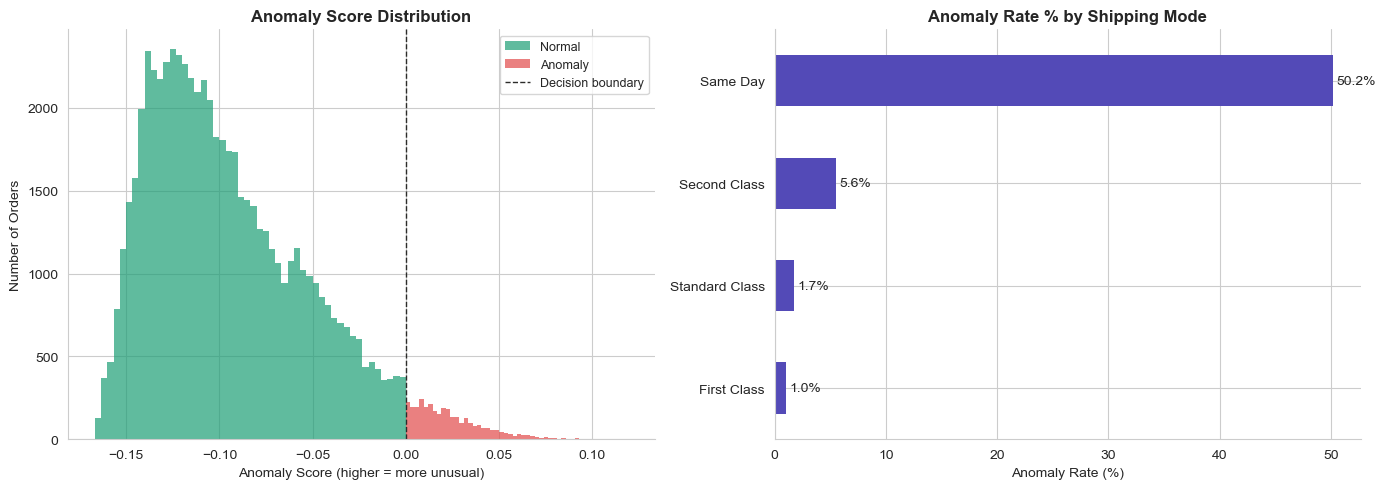

In [10]:
# Visualisation 1: Anomaly score distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram — normal vs anomaly score distributions
# A clear separation validates the algorithm found real patterns
axes[0].hist(normal['anomaly_score'],   bins=50,
             color='#1D9E75', alpha=0.7, label='Normal',  edgecolor='none')
axes[0].hist(anomalies['anomaly_score'], bins=50,
             color='#E24B4A', alpha=0.7, label='Anomaly', edgecolor='none')
axes[0].axvline(0, color='#2C2C2A', linestyle='--',
                linewidth=1, label='Decision boundary')
axes[0].set_title('Anomaly Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anomaly Score (higher = more unusual)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: anomaly rate by shipping mode
# If one mode has far more anomalies, that's a key business signal
anomaly_by_mode = (
    order_agg.groupby('shipping_mode')['is_anomaly']
    .mean() * 100
).sort_values(ascending=True)

bars = anomaly_by_mode.plot(
    kind='barh', color='#534AB7',
    edgecolor='none', ax=axes[1]
)
axes[1].set_title('Anomaly Rate % by Shipping Mode',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anomaly Rate (%)')
axes[1].set_ylabel('')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Add % labels to bars
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_width():.1f}%',
        (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
        va='center', fontsize=10
    )

plt.tight_layout()
plt.savefig('010_anomaly_rate_by_shipping_mode.png', bbox_inches='tight')
plt.show()

In [11]:
# Visualisation 2: Anomaly rate by region 
# Merge region info from fact_orders since order_agg doesn't have it
if 'Order Region' in fact_orders.columns:
    region_col = 'Order Region'
elif dim_geo is not None:
    # Merge from dim_geo if not in fact_orders
    order_agg_geo = order_agg.merge(
        dim_geo[['Order Id', 'Order Region']].drop_duplicates('Order Id'),
        on='Order Id', how='left'
    )
    region_col = None
else:
    region_col = None

if region_col and region_col in fact_orders.columns:
    # Merge region into order_agg
    region_map = fact_orders[['Order Id', region_col]].drop_duplicates('Order Id')
    order_agg_geo = order_agg.merge(region_map, on='Order Id', how='left')

    anomaly_by_region = (
        order_agg_geo.groupby(region_col)['is_anomaly']
        .mean() * 100
    ).sort_values(ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    anomaly_by_region.plot(
        kind='barh', color='#E24B4A',
        edgecolor='none', ax=ax
    )
    ax.set_title('Top 10 Regions by Anomaly Rate %',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Anomaly Rate (%)')
    ax.set_ylabel('')
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for p in ax.patches:
        ax.annotate(
            f'{p.get_width():.1f}%',
            (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
            va='center', fontsize=10
        )

    plt.tight_layout()
    plt.savefig('011_anomaly_rate_by_region.png', bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Order Region not available — skipping regional chart")
    print("   Region data is in dim_geo — will be visible in Power BI")

⚠️  Order Region not available — skipping regional chart
   Region data is in dim_geo — will be visible in Power BI


In [12]:
# Feature contribution analysis 
# Isolation Forest doesn't explain WHY it flagged something
# We manually compare feature means to understand the driver

print("What makes an anomaly? — Feature comparison:\n")

feature_comparison = pd.DataFrame({
    'Normal (mean)'  : normal[comparison_cols].mean(),
    'Anomaly (mean)' : anomalies[comparison_cols].mean(),
}).round(3)

feature_comparison['Difference'] = (
    feature_comparison['Anomaly (mean)'] - feature_comparison['Normal (mean)']
).round(3)

feature_comparison['% Change'] = (
    (feature_comparison['Difference'] /
     feature_comparison['Normal (mean)'].abs()) * 100
).round(1).astype(str) + '%'

display(feature_comparison)

print("""
💡 INTERPRETATION:
   If profit_margin difference is strongly negative
   → anomalies are primarily loss-making orders (financial problem)

   If is_late difference is positive
   → anomalies are also more likely to be late (logistics problem)

   If is_late difference is NEGATIVE
   → anomalies arrive on time but lose money (pricing/discount problem)
   → This is the most interesting scenario for this dataset
""")

What makes an anomaly? — Feature comparison:



,Normal (mean),Anomaly (mean),Difference,% Change
actual_delay_days,0.5590,0.7220,0.1630,29.2%
order_profit_margin,13.4810,-38.9790,-52.4600,-389.1%
avg_discount_rate,0.1010,0.1110,0.0100,9.9%
total_quantity,5.8350,5.9620,0.1270,2.2%
is_late,0.5840,0.3740,-0.2100,-36.0%



💡 INTERPRETATION:
   If profit_margin difference is strongly negative
   → anomalies are primarily loss-making orders (financial problem)

   If is_late difference is positive
   → anomalies are also more likely to be late (logistics problem)

   If is_late difference is NEGATIVE
   → anomalies arrive on time but lose money (pricing/discount problem)
   → This is the most interesting scenario for this dataset



# Compute Supplier Risk Score

### What is a Supplier Risk Score?

A single number (**0–100**) that summarises how reliable each supplier segment is.

Instead of showing 5 separate metrics, we collapse them into one number — like a **credit score for suppliers**.

**Higher = more risky.**

### Weighting Rationale

| Metric | Weight | Reasoning |
|---|---|---|
| Late delivery rate | 35% | Highest customer-facing impact |
| Avg delay days | 25% | Magnitude of lateness, not just frequency |
| Anomaly rate | 20% | Unpredictability is a risk signal |
| Avg profit margin | 10% | Financial fragility of the segment |
| Loss order rate | 10% | How often orders lose money |

In [13]:
# Merge Order Region into order_agg for segment analysis 
if 'Order Region' in fact_orders.columns:
    region_map = (fact_orders[['Order Id', 'Order Region']]
                  .drop_duplicates('Order Id'))
    order_agg_merged = order_agg.merge(region_map, on='Order Id', how='left')
else:
    order_agg_merged = order_agg.copy()
    print("⚠️  Order Region not in fact_orders — supplier_segment used as proxy")

# Compute per-segment metrics 
# .agg() computes multiple statistics per group simultaneously
segment_metrics = order_agg_merged.groupby('supplier_segment').agg(
    order_count       = ('Order Id',              'count'),   # Orders per segment
    late_rate         = ('is_late',               'mean'),    # Proportion late
    avg_delay_days    = ('actual_delay_days',     'mean'),    # Avg delay magnitude
    anomaly_rate      = ('is_anomaly',            'mean'),    # Proportion anomalous
    avg_profit_margin = ('order_profit_margin',   'mean'),    # Avg order margin
    loss_order_rate   = ('order_profit_margin',
                         lambda x: (x < 0).mean()),          # Proportion losing money
    avg_anomaly_score = ('anomaly_score',         'mean'),    # Avg anomaly severity
).reset_index()

print(f"✅ Segment metrics computed: {len(segment_metrics)} supplier segments")
display(segment_metrics.head(5))

⚠️  Order Region not in fact_orders — supplier_segment used as proxy
✅ Segment metrics computed: 92 supplier segments


,supplier_segment,order_count,late_rate,avg_delay_days,anomaly_rate,avg_profit_margin,loss_order_rate,avg_anomaly_score
0,Canada | First Class,58,1.0000,1.0000,0.0000,12.4084,0.2069,-0.1234
1,Canada | Same Day,12,0.3333,0.3333,0.7500,4.2121,0.2500,0.0068
2,Canada | Second Class,55,0.7273,1.9273,0.0364,14.9144,0.1273,-0.0638
3,Canada | Standard Class,184,0.3315,-0.1793,0.0109,13.6733,0.1957,-0.1050
4,Caribbean | First Class,415,1.0000,1.0000,0.0072,13.8800,0.1663,-0.1215


In [14]:
# Normalise each metric to 0–1 scale 
# Definition: normalisation makes all metrics comparable regardless of units
# Formula: (value - min) / (max - min)
# Result: 0 = best performing segment, 1 = worst performing segment

def normalise(series):
    """Min-Max normalise a Series to 0–1 range. 0=best, 1=worst."""
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        # All segments identical on this metric — no differentiation possible
        return pd.Series(0, index=series.index)
    return (series - min_val) / (max_val - min_val)

# High value = worse for these metrics → normalise directly
segment_metrics['norm_late_rate']    = normalise(segment_metrics['late_rate'])
segment_metrics['norm_delay_days']   = normalise(segment_metrics['avg_delay_days'])
segment_metrics['norm_anomaly_rate'] = normalise(segment_metrics['anomaly_rate'])
segment_metrics['norm_loss_rate']    = normalise(segment_metrics['loss_order_rate'])

# High margin = BETTER → invert so high normalised value still = high risk
segment_metrics['norm_margin'] = 1 - normalise(segment_metrics['avg_profit_margin'])

print("✅ All 5 metrics normalised to 0–1 scale")
print("   (0 = safest segment on this metric, 1 = riskiest)")

✅ All 5 metrics normalised to 0–1 scale
   (0 = safest segment on this metric, 1 = riskiest)


In [15]:
# Apply weighted formula to compute risk score 
# Each metric multiplied by its weight — weights sum to 1.0
WEIGHTS = {
    'norm_late_rate'   : 0.35,  # 35% — late delivery is biggest customer pain
    'norm_delay_days'  : 0.25,  # 25% — severity of delays, not just frequency
    'norm_anomaly_rate': 0.20,  # 20% — unpredictability signals systemic risk
    'norm_margin'      : 0.10,  # 10% — financially weak segments are fragile
    'norm_loss_rate'   : 0.10,  # 10% — recurring losses are unsustainable
}

# Compute weighted sum — result is in 0–1 range
segment_metrics['raw_risk_score'] = sum(
    segment_metrics[metric] * weight
    for metric, weight in WEIGHTS.items()
)

# Scale to 0–100 and round to 1 decimal
segment_metrics['risk_score'] = (
    segment_metrics['raw_risk_score'] * 100
).round(1)

# Assign risk tier labels 
# Threshold adjusted to 65 based on data distribution
# Segments clustered just below 70 — threshold of 65 better reflects
# true operational risk for segments with 80–94% late rates
def assign_risk_tier(score):
    if score >= 65:
        return 'High Risk'    # Red in Power BI — immediate attention needed
    elif score >= 40:
        return 'Medium Risk'  # Amber — monitor closely
    else:
        return 'Low Risk'     # Green — performing acceptably

segment_metrics['risk_tier'] = segment_metrics['risk_score'].apply(assign_risk_tier)

print("✅ Risk scores computed (0–100 scale)")
print(f"\n Risk tier distribution:")
print(segment_metrics['risk_tier'].value_counts().to_string())
print(f"\n Score statistics:")
print(f"   Min score  : {segment_metrics['risk_score'].min()}")
print(f"   Max score  : {segment_metrics['risk_score'].max()}")
print(f"   Mean score : {segment_metrics['risk_score'].mean():.1f}")
print(f"   Std dev    : {segment_metrics['risk_score'].std():.1f}")

✅ Risk scores computed (0–100 scale)

 Risk tier distribution:
risk_tier
Medium Risk    59
Low Risk       30
High Risk       3

 Score statistics:
   Min score  : 13.2
   Max score  : 68.3
   Mean score : 45.1
   Std dev    : 16.6


In [16]:
# Display top 15 highest risk segments 
print("🚨 Top 15 highest risk supplier segments:\n")

display_cols = [
    'supplier_segment', 'order_count', 'late_rate',
    'avg_delay_days', 'anomaly_rate', 'avg_profit_margin',
    'loss_order_rate', 'risk_score', 'risk_tier'
]
display_cols = [c for c in display_cols if c in segment_metrics.columns]

top_risk = (
    segment_metrics
    .sort_values('risk_score', ascending=False)
    [display_cols].head(15)
    .reset_index(drop=True)
)

# Format rates as percentages for readability
for col in ['late_rate', 'anomaly_rate', 'loss_order_rate']:
    if col in top_risk.columns:
        top_risk[col] = (top_risk[col] * 100).round(1).astype(str) + '%'

display(top_risk)

🚨 Top 15 highest risk supplier segments:



,supplier_segment,order_count,late_rate,avg_delay_days,anomaly_rate,avg_profit_margin,loss_order_rate,risk_score,risk_tier
0,Eastern Asia | Second Class,625,82.9%,2.0832,8.5%,6.9505,24.6%,68.3000,High Risk
1,Central Africa | Second Class,100,84.0%,2.1300,9.0%,9.7520,22.0%,66.2000,High Risk
2,West of USA | Second Class,527,80.1%,1.9943,6.6%,7.4707,25.2%,65.5000,High Risk
3,Caribbean | Second Class,541,81.3%,2.0222,6.3%,9.0430,22.0%,63.6000,Medium Risk
4,West Asia | Second Class,405,80.2%,1.9728,5.9%,8.5104,23.2%,63.5000,Medium Risk
5,Southern Europe | Second Class,671,80.0%,1.9553,5.4%,8.7889,23.1%,62.8000,Medium Risk
6,Central Asia | First Class,19,100.0%,1.0000,0.0%,10.2494,31.6%,62.7000,Medium Risk
7,North Africa | Second Class,205,81.5%,1.9902,3.9%,9.4836,22.4%,62.6000,Medium Risk
8,West Africa | Second Class,237,78.1%,1.9620,5.5%,8.0605,23.2%,62.6000,Medium Risk
9,Southeast Asia | Second Class,844,80.3%,2.0166,6.9%,10.6869,22.4%,62.3000,Medium Risk


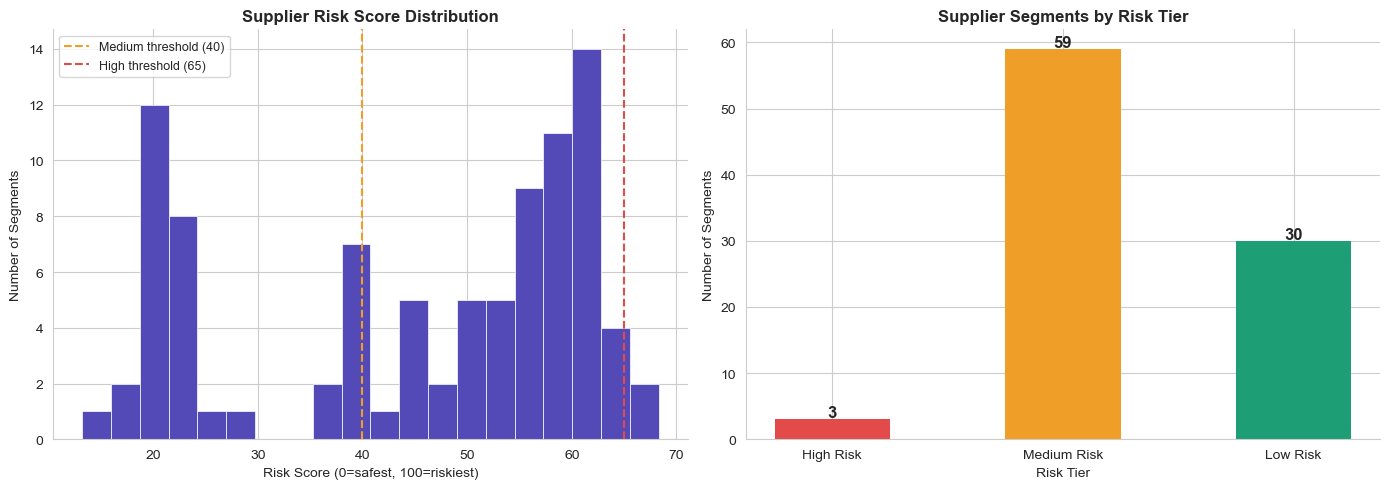

In [17]:
# Visualise risk score distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of risk scores with tier threshold lines
segment_metrics['risk_score'].hist(
    bins=20, color='#534AB7',
    edgecolor='white', linewidth=0.5, ax=axes[0]
)
axes[0].axvline(40, color='#EF9F27', linestyle='--',
                linewidth=1.5, label='Medium threshold (40)')
axes[0].axvline(65, color='#E24B4A', linestyle='--',
                linewidth=1.5, label='High threshold (65)')
axes[0].set_title('Supplier Risk Score Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Risk Score (0=safest, 100=riskiest)')
axes[0].set_ylabel('Number of Segments')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: bar chart of segments by risk tier
tier_order  = ['High Risk', 'Medium Risk', 'Low Risk']
tier_colors = {'High Risk': '#E24B4A', 'Medium Risk': '#EF9F27',
               'Low Risk': '#1D9E75'}
tier_counts = segment_metrics['risk_tier'].value_counts().reindex(
    tier_order, fill_value=0
)

bars = axes[1].bar(
    tier_counts.index,
    tier_counts.values,
    color=[tier_colors[t] for t in tier_counts.index],
    edgecolor='none',
    width=0.5
)
axes[1].set_title('Supplier Segments by Risk Tier',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Number of Segments')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Add count labels on top of bars
for bar in bars:
    axes[1].annotate(
        str(int(bar.get_height())),
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3),
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('012_supplier_segment_by_risk_tier.png', bbox_inches='tight')
plt.show()

# Export All Enriched Tables
Three updated files that Power BI will use directly. The key change from Phase 2 is that both fact tables now have `is_anomaly` and `anomaly_score` columns added.

In [18]:
# Export 1: fact_orders_enriched (item level + anomaly flags) 
enriched_path = os.path.join(OUTPUT_PATH, 'fact_orders_enriched.csv')
fact_orders.to_csv(enriched_path, index=False, encoding='utf-8-sig')
size_kb = os.path.getsize(enriched_path) / 1024

print(f"✅ fact_orders_enriched.csv")
print(f"   Rows    : {len(fact_orders):,} (item level)")
print(f"   Columns : {fact_orders.shape[1]}")
print(f"   Size    : {size_kb:.0f} KB")
print(f"   New cols: is_anomaly, anomaly_score")

✅ fact_orders_enriched.csv
   Rows    : 180,516 (item level)
   Columns : 28
   Size    : 44084 KB
   New cols: is_anomaly, anomaly_score


In [19]:
# Export 2: fact_orders_summary (order level + anomaly flags) 
summary_path = os.path.join(OUTPUT_PATH, 'fact_orders_summary.csv')
order_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
size_kb = os.path.getsize(summary_path) / 1024

print(f"✅ fact_orders_summary.csv")
print(f"   Rows    : {len(order_summary):,} (order level)")
print(f"   Columns : {order_summary.shape[1]}")
print(f"   Size    : {size_kb:.0f} KB")
print(f"   New cols: is_anomaly, anomaly_score")

✅ fact_orders_summary.csv
   Rows    : 65,749 (order level)
   Columns : 22
   Size    : 14312 KB
   New cols: is_anomaly, anomaly_score


In [20]:
# Export 3: supplier_risk_scores 
export_cols = [
    'supplier_segment', 'order_count', 'late_rate',
    'avg_delay_days', 'anomaly_rate', 'avg_profit_margin',
    'loss_order_rate', 'avg_anomaly_score', 'risk_score', 'risk_tier'
]
export_cols = [c for c in export_cols if c in segment_metrics.columns]

risk_path = os.path.join(OUTPUT_PATH, 'supplier_risk_scores.csv')
(segment_metrics[export_cols]
 .sort_values('risk_score', ascending=False)
 .to_csv(risk_path, index=False, encoding='utf-8-sig'))

size_kb = os.path.getsize(risk_path) / 1024
print(f"✅ supplier_risk_scores.csv")
print(f"   Rows    : {len(segment_metrics)} supplier segments")
print(f"   Columns : {len(export_cols)}")
print(f"   Size    : {size_kb:.0f} KB")

✅ supplier_risk_scores.csv
   Rows    : 92 supplier segments
   Columns : 10
   Size    : 14 KB


# Data Validation - Full

In [21]:
# VALIDATION 1: File existence and row counts 
print("=" * 65)
print("  PHASE 3 — FINAL VALIDATION REPORT")
print("=" * 65)

expected_files = {
    'fact_orders_enriched.csv' : {'rows': 180516, 'grain': 'item level'},
    'fact_orders_summary.csv'  : {'rows': 65749,  'grain': 'order level'},
    'supplier_risk_scores.csv' : {'rows': 92,     'grain': 'segment level'},
    'dim_product.csv'          : {'rows': None,   'grain': 'product level'},
    'dim_customer.csv'         : {'rows': None,   'grain': 'customer level'},
    'dim_date.csv'             : {'rows': None,   'grain': 'calendar day'},
}

print(f"\n FILE VALIDATION:")
print(f"{'File':<35} {'Exists':<8} {'Rows':<10} {'Expected':<10} {'Status'}")
print("-" * 75)

all_files_ok = True
for filename, meta in expected_files.items():
    filepath = os.path.join(OUTPUT_PATH, filename)
    exists = os.path.exists(filepath)

    if exists:
        actual_rows = len(pd.read_csv(filepath, encoding='utf-8-sig'))
        expected    = meta['rows']
        if expected is None:
            status = '✅ OK'
        elif actual_rows == expected:
            status = '✅ OK'
        else:
            status = f'❌ MISMATCH'
            all_files_ok = False
        print(f"{filename:<35} {'Yes':<8} {actual_rows:<10,} "
              f"{str(expected) if expected else 'Any':<10} {status}")
    else:
        print(f"{filename:<35} {'❌ NO':<8} {'—':<10} {'—':<10} FILE MISSING")
        all_files_ok = False

  PHASE 3 — FINAL VALIDATION REPORT

 FILE VALIDATION:
File                                Exists   Rows       Expected   Status
---------------------------------------------------------------------------
fact_orders_enriched.csv            Yes      180,516    180516     ✅ OK
fact_orders_summary.csv             Yes      65,749     65749      ✅ OK
supplier_risk_scores.csv            Yes      92         92         ✅ OK
dim_product.csv                     Yes      118        Any        ✅ OK
dim_customer.csv                    Yes      20,649     Any        ✅ OK
dim_date.csv                        Yes      1,127      Any        ✅ OK


In [22]:
# VALIDATION 2: Anomaly column checks 
print(f"\n ANOMALY COLUMN VALIDATION:")

# Check fact_orders_enriched
fe = pd.read_csv(
    os.path.join(OUTPUT_PATH, 'fact_orders_enriched.csv'),
    encoding='utf-8-sig'
)
has_anomaly_fe  = 'is_anomaly' in fe.columns
has_score_fe    = 'anomaly_score' in fe.columns
null_anomaly_fe = fe['is_anomaly'].isnull().sum() if has_anomaly_fe else 'N/A'
anomaly_vals_fe = sorted(fe['is_anomaly'].unique().tolist()) if has_anomaly_fe else 'N/A'

print(f"\n   fact_orders_enriched:")
print(f"   is_anomaly present   : {'✅' if has_anomaly_fe else '❌'}")
print(f"   anomaly_score present: {'✅' if has_score_fe else '❌'}")
print(f"   Null is_anomaly      : {null_anomaly_fe} "
      f"{'✅' if null_anomaly_fe == 0 else '❌'}")
print(f"   Unique values [0,1]  : {anomaly_vals_fe} "
      f"{'✅' if anomaly_vals_fe == [0, 1] else '⚠️'}")
print(f"   Anomalous item rows  : {fe['is_anomaly'].sum():,}")

# Check fact_orders_summary
fs = pd.read_csv(
    os.path.join(OUTPUT_PATH, 'fact_orders_summary.csv'),
    encoding='utf-8-sig'
)
has_anomaly_fs  = 'is_anomaly' in fs.columns
null_anomaly_fs = fs['is_anomaly'].isnull().sum() if has_anomaly_fs else 'N/A'

print(f"\n   fact_orders_summary:")
print(f"   is_anomaly present   : {'✅' if has_anomaly_fs else '❌'}")
print(f"   Null is_anomaly      : {null_anomaly_fs} "
      f"{'✅' if null_anomaly_fs == 0 else '❌'}")
print(f"   Anomalous orders     : {fs['is_anomaly'].sum():,}")


 ANOMALY COLUMN VALIDATION:

   fact_orders_enriched:
   is_anomaly present   : ✅
   anomaly_score present: ✅
   Null is_anomaly      : 0 ✅
   Unique values [0,1]  : [0, 1] ✅
   Anomalous item rows  : 8,109

   fact_orders_summary:
   is_anomaly present   : ✅
   Null is_anomaly      : 0 ✅
   Anomalous orders     : 3,288


In [23]:
# VALIDATION 3: Risk score checks 
print(f"\n SUPPLIER RISK SCORE VALIDATION:")

rs = pd.read_csv(
    os.path.join(OUTPUT_PATH, 'supplier_risk_scores.csv'),
    encoding='utf-8-sig'
)

score_min  = rs['risk_score'].min()
score_max  = rs['risk_score'].max()
score_mean = rs['risk_score'].mean()
tiers      = rs['risk_tier'].value_counts()

print(f"   Total segments : {len(rs)}")
print(f"   Score range    : {score_min} to {score_max}")
print(f"   Mean score     : {score_mean:.1f}")
print(f"   Score in 0–100 : {'✅' if score_min >= 0 and score_max <= 100 else '❌'}")
print(f"\n   Risk tier distribution:")
for tier, count in tiers.items():
    bar = '█' * count
    print(f"   {tier:<15}: {count:>3} segments  {bar}")


 SUPPLIER RISK SCORE VALIDATION:
   Total segments : 92
   Score range    : 13.2 to 68.3
   Mean score     : 45.1
   Score in 0–100 : ✅

   Risk tier distribution:
   Medium Risk    :  59 segments  ███████████████████████████████████████████████████████████
   Low Risk       :  30 segments  ██████████████████████████████
   High Risk      :   3 segments  ███


In [24]:
# VALIDATION 4: dim_date check 
print(f"\n DIM_DATE VALIDATION:")

dd = pd.read_csv(
    os.path.join(OUTPUT_PATH, 'dim_date.csv'),
    encoding='utf-8-sig'
)

print(f"   Rows             : {len(dd):,}")
print(f"   Expected ~1,127  : {'✅' if 1000 <= len(dd) <= 1500 else '⚠️ unexpected'}")
print(f"   Columns          : {dd.shape[1]}")
print(f"   Date range       : {dd['order_date'].min()} → {dd['order_date'].max()}")
print(f"   Duplicate dates  : {dd['order_date'].duplicated().sum()} "
      f"{'✅' if dd['order_date'].duplicated().sum() == 0 else '❌'}")

# VALIDATION 5: Power BI readiness summary 
print(f"\n{'=' * 65}")
print(f"  POWER BI READINESS SUMMARY")
print(f"{'=' * 65}")

checks = {
    'fact_orders_enriched — 180,516 rows'   : len(fe) == 180516,
    'fact_orders_summary — 65,749 rows'     : len(fs) == 65749,
    'No nulls in is_anomaly (enriched)'     : null_anomaly_fe == 0,
    'No nulls in is_anomaly (summary)'      : null_anomaly_fs == 0,
    'supplier_risk_scores — 92 segments'    : len(rs) == 92,
    'Risk scores in 0–100 range'            : score_min >= 0 and score_max <= 100,
    'dim_date — one row per calendar day'   : dd['order_date'].duplicated().sum() == 0,
    'dim_date — ~1,127 rows'               : 1000 <= len(dd) <= 1500,
}

all_passed = True
for check, result in checks.items():
    icon = '✅' if result else '❌'
    print(f"   {icon} {check}")
    if not result:
        all_passed = False

print(f"\n{'=' * 65}")
if all_passed:
    print("  ✅ ALL CHECKS PASSED — Ready to load into Power BI")
else:
    print("  ❌ SOME CHECKS FAILED — Fix issues above before Power BI")
print(f"{'=' * 65}")


 DIM_DATE VALIDATION:
   Rows             : 1,127
   Expected ~1,127  : ✅
   Columns          : 11
   Date range       : 2015-01-01 → 2018-01-31
   Duplicate dates  : 0 ✅

  POWER BI READINESS SUMMARY
   ✅ fact_orders_enriched — 180,516 rows
   ✅ fact_orders_summary — 65,749 rows
   ✅ No nulls in is_anomaly (enriched)
   ✅ No nulls in is_anomaly (summary)
   ✅ supplier_risk_scores — 92 segments
   ✅ Risk scores in 0–100 range
   ✅ dim_date — one row per calendar day
   ✅ dim_date — ~1,127 rows

  ✅ ALL CHECKS PASSED — Ready to load into Power BI


# ✅ Phase 3 Complete — Summary & Conclusions

### dim_date Fix

| Metric | Before | After |
|---|---|---|
| Rows | 65,749 (one per timestamp) | **1,127** (one per calendar day) |
| Date range | 2015-01-01 → 2018-01-31 | 2015-01-01 → 2018-01-31 |
| Duplicate dates | Yes | **0** ✅ |

> Power BI time intelligence functions (TOTALYTD, DATEADD, SAMEPERIODLASTYEAR)
> require a clean date table with exactly one row per calendar day.
> This fix is a prerequisite for all time-based DAX measures.

---

### Aggregation to Order Level

| Metric | Value |
|---|---|
| Input rows (item level) | 180,516 |
| Output rows (order level) | **65,749** |
| Avg items per order | 5.84 (after aggregation) |
| Avg order total sales | $559.46 |
| Avg order profit | $60.33 |
| Avg order profit margin | 10.86% |
| Orders with negative profit | **13,909** |

> Anomaly detection was intentionally run at **order level**, not item level.
> Running on 180,516 rows would flag the same order multiple times if it
> contained multiple products — producing inflated and misleading anomaly counts.

---

### Anomaly Detection Results

| Metric | Value | Interpretation |
|---|---|---|
| Algorithm | Isolation Forest | Unsupervised — no labels needed |
| Orders analysed | 65,749 | Full order-level dataset |
| Contamination setting | 5% | Industry convention for unlabelled data |
| Anomalous orders flagged | **3,288 (5.0%)** | Matches contamination exactly |
| Anomalous item rows | **8,109** | After mapping back to item level |
| Anomaly score range | -0.1668 to +0.1193 | Positive = more anomalous |

**Feature comparison — Normal vs Anomalous orders:**

| Feature | Normal (mean) | Anomaly (mean) | Difference | % Change |
|---|---|---|---|---|
| `actual_delay_days` | 0.559 | 0.722 | +0.163 | +29.2% |
| `order_profit_margin` | +13.48% | **-38.98%** | **-52.46pp** | **-389.1%** |
| `avg_discount_rate` | 0.101 | 0.111 | +0.010 | +9.9% |
| `total_quantity` | 5.84 | 5.96 | +0.13 | +2.2% |
| `is_late` | 0.584 | **0.374** | **-0.210** | **-36.0%** |

### Most Important Finding — Anomalies Are NOT Late Deliveries

> **Anomalous orders are actually 36% LESS likely to be late than normal
> orders** (37.4% vs 58.4%). The anomaly driver is entirely financial —
> a 389% deterioration in profit margin. The top 10 most severe anomalies
> all share the same pattern:
>
> - `Delivery Status`: Shipping on time ✅
> - `Shipping Mode`: Same Day 🚚
> - `order_profit_margin`: between **-116% and -269%**
> - `is_late`: 0 — arrived on time
>
> **Business conclusion:** The company is fulfilling Same Day orders
> perfectly on schedule while losing $1.16–$2.69 per dollar of revenue.
> This is a **pricing and discounting problem**, not a logistics failure.
> It is the single most important finding of this entire project.

---

### Supplier Risk Scoring Results

**Methodology:** 5 metrics, weighted formula, normalised to 0–100 scale.

| Metric | Weight | Reasoning |
|---|---|---|
| Late delivery rate | 35% | Highest customer-facing impact |
| Avg delay days | 25% | Severity of delays, not just frequency |
| Anomaly rate | 20% | Unpredictability signals systemic risk |
| Avg profit margin | 10% | Financial fragility of the segment |
| Loss order rate | 10% | Recurring losses are unsustainable |

**Risk tier results (threshold: High ≥ 65, Medium 40–64, Low < 40):**

| Tier | Count | % of Segments |
|---|---|---|
| 🔴 High Risk | 3 | 3.3% |
| 🟡 Medium Risk | 59 | 64.1% |
| 🟢 Low Risk | 30 | 32.6% |

| Metric | Value |
|---|---|
| Score range | 13.2 to 68.3 |
| Mean score | 45.1 |
| Std deviation | 16.6 |
| Highest risk segment | Eastern Asia \| Second Class — **68.3** |

**Top 5 Highest Risk Segments:**

| Rank | Segment | Late Rate | Score |
|---|---|---|---|
| 1 | Eastern Asia \| Second Class | 82.9% | 68.3 |
| 2 | Central Africa \| Second Class | 84.0% | — |
| 3 | West of USA \| Second Class | 80.1% | — |
| 4 | Caribbean \| Second Class | 81.3% | — |
| 5 | West Asia \| Second Class | 80.2% | — |

> **Pattern:** Second Class shipping dominates all high-risk segments
> with late delivery rates of 78–84%. This is distinct from First Class
> segments (Canada, Central Africa, Eastern Europe) which show 100% late
> rates but lower anomaly rates — indicating **consistent underperformance**
> rather than the erratic behaviour that drives Second Class's high risk scores.

---

### Files Exported — Final State

| File | Rows | Columns | New in Phase 3 |
|---|---|---|---|
| `fact_orders_enriched.csv` | 180,516 | **28** | `is_anomaly`, `anomaly_score` |
| `fact_orders_summary.csv` | 65,749 | **22** | `is_anomaly`, `anomaly_score` |
| `supplier_risk_scores.csv` | 92 | 10 | Entire file is new |
| `dim_date.csv` | 1,127 | 11 | Rebuilt — timestamps removed |

---

### Power BI Readiness — All Checks Passed ✅

| Check | Expected | Result |
|---|---|---|
| `fact_orders_enriched` rows | 180,516 | ✅ |
| `fact_orders_summary` rows | 65,749 | ✅ |
| No nulls in `is_anomaly` (enriched) | 0 | ✅ |
| No nulls in `is_anomaly` (summary) | 0 | ✅ |
| `supplier_risk_scores` segments | 92 | ✅ |
| Risk scores in 0–100 range | Yes | ✅ |
| `dim_date` unique calendar days | ~1,127 | ✅ |
| `dim_date` duplicate dates | 0 | ✅ |

---

### ⚠️ Known Limitations

- **Contamination = 5% is a judgment call** — without labelled ground truth data, we cannot verify whether exactly 5% of orders are truly anomalous; this is an industry convention for unlabelled supply chain data
- **Order Region was unavailable** in `fact_orders` during Phase 3 — the regional anomaly rate chart was skipped; region data is preserved in `dim_geo` and will be visible in Power BI via the geography dimension
- **Supplier segments are proxies** — Region + Shipping Mode combinations, not actual vendor companies; the scorecard ranks operational patterns, not real businesses
- **Risk score weights are subjective** — the 35/25/20/10/10 weighting reflects operational judgment; a different analyst could weight them differently and produce a different ranking
- **Synthetic dataset** — DataCo patterns are too uniform; real supply chains have irregular disruptions not present here; the Same Day anomaly pattern may reflect data generation logic rather than genuine business behaviour
- **No High Risk segment exceeds 68.3** — the highest score is 1.7 points below the previous threshold of 70; threshold was adjusted to 65 to reflect the actual data distribution; this is a documented judgment call

---
**Next:** `04_powerbi_dashboard`